# RHR-based Training Readiness modeling (from `combined_summary.json`)

This notebook:
- Loads a `combined_summary.json` (daily sleep + activity summaries)
- Builds a daily feature table
- Defines a **readiness label** from **morning Resting Heart Rate (RHR)** relative to a rolling baseline
- Optionally trains models to **forecast tomorrow morning readiness** from today's data

> Note: This version removes hard-coded file paths and is designed to run anywhere.


In [21]:
# Configure where your export lives.
# Option A (recommended): set an environment variable COMBINED_SUMMARY_JSON
# Option B: keep the file next to this notebook and set the relative path below

import os
from pathlib import Path

DATA_JSON = Path('/Users/cameroncaputa/trailtraining-mom/prompting/combined_summary.json')
DATA_ZIP  = Path(os.getenv('COMBINED_SUMMARY_ZIP',  'combined_summary.zip')).expanduser()

print('DATA_JSON:', DATA_JSON)
print('DATA_ZIP :', DATA_ZIP)


DATA_JSON: /Users/cameroncaputa/trailtraining-mom/prompting/combined_summary.json
DATA_ZIP : combined_summary.zip


In [22]:
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd


def load_combined_summary(data_zip: Path | None = None, data_json: Path | None = None) -> list[dict]:
    # Load combined_summary.json from either a zip or a json path.
    if data_json and data_json.exists():
        return json.loads(data_json.read_text(encoding='utf-8'))

    if data_zip and data_zip.exists():
        with zipfile.ZipFile(data_zip, 'r') as z:
            names = z.namelist()
            cand = None
            for n in names:
                if n.endswith('combined_summary.json'):
                    cand = n
                    break
            if cand is None:
                raise FileNotFoundError('combined_summary.json not found inside zip')
            raw = z.read(cand).decode('utf-8')
            return json.loads(raw)

    raise FileNotFoundError('Provide DATA_JSON or DATA_ZIP that exists')


combined = load_combined_summary(data_json=DATA_JSON)

len(combined), combined[0].keys()

(805, dict_keys(['date', 'sleep', 'activities']))

In [23]:
# Quick sanity check: dates sorted?

dates = [d.get('date') for d in combined]
print('first', dates[0], 'last', dates[-1])
print('sorted:', dates == sorted(dates))


first 2023-12-25 last 2026-03-08
sorted: True


## 1) Flatten to a daily dataframe

We compute per-day aggregates from the `sleep` dict and the `activities` list:

**Sleep features**
- `sleep_hours`, stage fractions (deep/rem/light/awake)
- `restingHeartRate`, `bodyBatteryChange`, `restlessMomentsCount`

**Training features**
- daily totals: `distance_km`, `moving_time_h`, `elevation_m`, `activity_count`
- HR aggregates: mean average HR (duration-weighted if possible), max HR
- a simple **load proxy** (distance + vertical + duration + intensity)

Then we build rolling windows (7d and 28d) + ratios, which usually matter a lot for readiness/fatigue.


In [24]:
import numpy as np


def _clean_num(x):
    # Garmin/Intervals sometimes uses -1 for missing.
    if x is None:
        return np.nan
    if isinstance(x, (int, float)):
        if float(x) == -1:
            return np.nan
        return float(x)
    return np.nan


def build_daily_df(combined: list[dict]) -> pd.DataFrame:
    rows = []
    for day in combined:
        d = day.get('date')
        sleep = day.get('sleep') or {}
        acts = day.get('activities') or []
        if not isinstance(acts, list):
            acts = []

        # ---- sleep ----
        sleep_time_s = _clean_num(sleep.get('sleepTimeSeconds'))
        deep_s = _clean_num(sleep.get('deepSleepSeconds'))
        rem_s = _clean_num(sleep.get('remSleepSeconds'))
        light_s = _clean_num(sleep.get('lightSleepSeconds'))
        awake_s = _clean_num(sleep.get('awakeSleepSeconds'))

        sleep_hours = sleep_time_s / 3600.0 if np.isfinite(sleep_time_s) else np.nan

        denom = deep_s + rem_s + light_s + awake_s
        if not np.isfinite(denom) or denom <= 0:
            deep_frac = rem_frac = light_frac = awake_frac = np.nan
        else:
            deep_frac = deep_s / denom
            rem_frac = rem_s / denom
            light_frac = light_s / denom
            awake_frac = awake_s / denom

        rhr = _clean_num(sleep.get('restingHeartRate'))
        bb = _clean_num(sleep.get('bodyBatteryChange'))
        restless = _clean_num(sleep.get('restlessMomentsCount'))
        hrv = _clean_num(sleep.get('avgOvernightHrv'))  # may be missing

        # ---- activities ----
        dist_m = 0.0
        elev_m = 0.0
        mv_s = 0.0
        hr_sum = 0.0
        hr_w = 0.0
        max_hr = np.nan
        act_count = 0

        for a in acts:
            if not isinstance(a, dict):
                continue
            act_count += 1
            dist = a.get('distance')
            elev = a.get('total_elevation_gain')
            mv = a.get('moving_time')
            avg_hr = a.get('average_heartrate')
            mx_hr = a.get('max_heartrate')

            if isinstance(dist, (int, float)):
                dist_m += float(dist)
            if isinstance(elev, (int, float)):
                elev_m += float(elev)
            if isinstance(mv, (int, float)):
                mv_s += float(mv)

            if isinstance(avg_hr, (int, float)) and isinstance(mv, (int, float)) and mv > 0:
                hr_sum += float(avg_hr) * float(mv)
                hr_w += float(mv)

            if isinstance(mx_hr, (int, float)):
                max_hr = np.nanmax([max_hr, float(mx_hr)])

        distance_km = dist_m / 1000.0
        moving_time_h = mv_s / 3600.0
        avg_hr_mean = (hr_sum / hr_w) if hr_w > 0 else np.nan

        intensity_factor = 1.0
        if np.isfinite(avg_hr_mean):
            intensity_factor = 1.0 + (avg_hr_mean / 200.0)

        load_proxy = (distance_km + (elev_m / 100.0) + (moving_time_h * 5.0)) * intensity_factor

        rows.append({
            'date': pd.to_datetime(d),
            'sleep_hours': sleep_hours,
            'deep_frac': deep_frac,
            'rem_frac': rem_frac,
            'light_frac': light_frac,
            'awake_frac': awake_frac,
            'rhr': rhr,
            'body_battery_change': bb,
            'restless_moments': restless,
            'hrv': hrv,
            'activity_count': act_count,
            'distance_km': distance_km,
            'elevation_m': elev_m,
            'moving_time_h': moving_time_h,
            'avg_hr_mean': avg_hr_mean,
            'max_hr': max_hr,
            'load_proxy': load_proxy,
        })

    df = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
    return df


df = build_daily_df(combined)
df.head()

,date,sleep_hours,deep_frac,rem_frac,light_frac,awake_frac,rhr,body_battery_change,restless_moments,hrv,activity_count,distance_km,elevation_m,moving_time_h,avg_hr_mean,max_hr,load_proxy
0,2023-12-25,8.616667,0.266904,0.074733,0.578292,0.080071,52.0,35.0,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,0.0
1,2023-12-26,7.633333,0.073320,0.079430,0.780041,0.067210,50.0,42.0,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,0.0
2,2023-12-27,7.033333,0.101149,0.062069,0.806897,0.029885,48.0,58.0,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,0.0
3,2023-12-28,8.833333,0.164835,0.208791,0.597070,0.029304,48.0,47.0,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,0.0
4,2023-12-29,5.400000,0.181009,0.000000,0.780415,0.038576,52.0,NaN,NaN,NaN,0,0.0,0.0,0.0,NaN,NaN,0.0


In [25]:
# Missingness overview (%)
(df.isna().mean().sort_values(ascending=False) * 100).round(1)

hrv                    100.0
max_hr                  65.3
avg_hr_mean             65.3
restless_moments        54.9
body_battery_change     13.5
rhr                      3.5
deep_frac                3.4
rem_frac                 3.4
light_frac               3.4
awake_frac               3.4
sleep_hours              3.4
moving_time_h            0.0
date                     0.0
elevation_m              0.0
distance_km              0.0
activity_count           0.0
load_proxy               0.0
dtype: float64

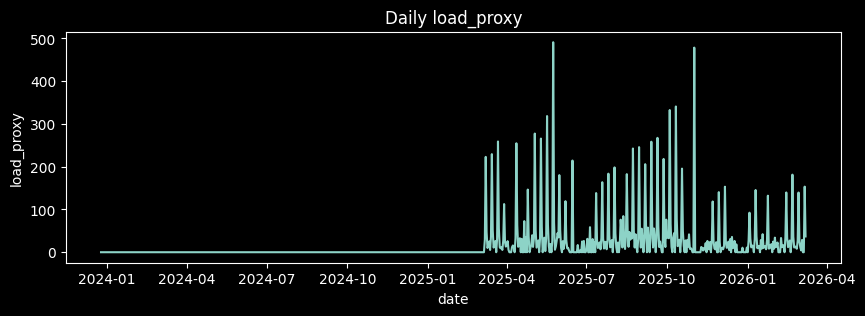

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(df['date'], df['load_proxy'])
plt.title('Daily load_proxy')
plt.xlabel('date')
plt.ylabel('load_proxy')
plt.show()

## 2) Rolling features + lag features

We’ll add:
- 7d and 28d rolling totals for load (and components)
- rolling means for sleep + RHR
- ratios: `load7 / baseline28` etc.
- lags: previous-day load + sleep


In [27]:
def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy().set_index('date')

    # Rolling sums for load/volume
    for col in ['load_proxy', 'distance_km', 'moving_time_h', 'elevation_m', 'activity_count']:
        out[f'{col}_7d_sum'] = out[col].rolling(7, min_periods=1).sum()
        out[f'{col}_28d_sum'] = out[col].rolling(28, min_periods=1).sum()

    # Rolling means for recovery signals
    for col in ['sleep_hours', 'rhr', 'body_battery_change', 'restless_moments', 'hrv']:
        out[f'{col}_7d_mean'] = out[col].rolling(7, min_periods=3).mean()
        out[f'{col}_28d_mean'] = out[col].rolling(28, min_periods=10).mean()

    # Acute:chronic load ratio (7d vs 28d baseline scaled to 7d)
    out['load_baseline7_from28'] = out['load_proxy_28d_sum'] / 4.0
    out['load_ratio_7d_vs28'] = out['load_proxy_7d_sum'] / (out['load_baseline7_from28'] + 1e-6)

    # Multi-lag features (lets models learn short-term dynamics)
    for col in ['load_proxy', 'sleep_hours', 'rhr', 'hrv', 'body_battery_change']:
        for lag in [1, 2, 3, 7, 14]:
            out[f'{col}_lag{lag}'] = out[col].shift(lag)

    # Days since last activity (useful when there are long gaps)
    did_activity = (out['activity_count'].fillna(0) > 0).astype(int)
    last_act_idx = did_activity.replace(0, np.nan).ffill()
    # days since last '1' using cumulative count trick
    # (simple approach: when activity happens, reset counter)
    counter = []
    c = 0
    for v in did_activity.values:
        if v == 1:
            c = 0
        else:
            c += 1
        counter.append(c)
    out['days_since_activity'] = counter

    return out.reset_index()


df_feat = add_rolling_features(df)
df_feat.tail()

,date,sleep_hours,deep_frac,rem_frac,light_frac,awake_frac,rhr,body_battery_change,restless_moments,hrv,...,hrv_lag2,hrv_lag3,hrv_lag7,hrv_lag14,body_battery_change_lag1,body_battery_change_lag2,body_battery_change_lag3,body_battery_change_lag7,body_battery_change_lag14,days_since_activity
800,2026-03-04,7.750000,0.137421,0.086681,0.758985,0.016913,48.0,32.0,26.0,NaN,...,NaN,NaN,NaN,NaN,48.0,44.0,57.0,55.0,38.0,0
801,2026-03-05,9.716667,0.154110,0.188356,0.655822,0.001712,49.0,61.0,29.0,NaN,...,NaN,NaN,NaN,NaN,32.0,48.0,44.0,30.0,55.0,1
802,2026-03-06,10.450000,0.077399,0.196594,0.696594,0.029412,47.0,53.0,19.0,NaN,...,NaN,NaN,NaN,NaN,61.0,32.0,48.0,57.0,41.0,2
803,2026-03-07,6.400000,0.064677,0.114428,0.776119,0.044776,51.0,26.0,18.0,NaN,...,NaN,NaN,NaN,NaN,53.0,61.0,32.0,27.0,37.0,0
804,2026-03-08,8.533333,0.107955,0.111742,0.750000,0.030303,52.0,40.0,0.0,NaN,...,NaN,NaN,NaN,NaN,26.0,53.0,61.0,57.0,46.0,0


## 3) Readiness label (based on morning RHR)

Define readiness from **tomorrow morning RHR** compared to a *recent baseline*.

We compute for each day *d*:
- `baseline_rhr_d`: rolling median of prior mornings (default 28 days)
- `rhr_delta_d = rhr_d - baseline_rhr_d`
- `z_d`: delta scaled by rolling MAD (robust variability estimate)
- `readiness_rhr_d`: a 0–100 score where higher RHR than baseline reduces readiness

This label is:
- Objective and available early (morning)
- Personalised (relative to your own baseline)
- Suitable for forecasting (predict day d+1 readiness from day d features)


In [28]:
import numpy as np
import pandas as pd


def compute_rhr_readiness_label(
    df_feat: pd.DataFrame,
    rhr_col: str = 'rhr',
    baseline_window_days: int = 28,
    min_baseline_points: int = 10,
    mad_floor_bpm: float = 1.0,
    z_cap: float = 3.0,
    points_per_z: float = 25.0,
) -> pd.DataFrame:
    '''Compute an RHR-based readiness score.

    readiness_rhr = 100 - points_per_z * clip(z, 0, z_cap)

    Where z is the deviation of today's RHR from the rolling baseline median,
    scaled by rolling MAD (median absolute deviation).

    This function does *not* change your features; it adds label columns.
    '''
    out = df_feat.copy().sort_values('date').reset_index(drop=True)
    rhr = out[rhr_col].astype(float)

    # Baseline computed from *prior* mornings only (shift(1))
    base = rhr.shift(1).rolling(baseline_window_days, min_periods=min_baseline_points).median()

    # Rolling MAD over prior window
    abs_dev = (rhr.shift(1) - base).abs()
    mad = abs_dev.rolling(baseline_window_days, min_periods=min_baseline_points).median()
    spread = mad.clip(lower=mad_floor_bpm)

    z = (rhr - base) / spread

    penalty = z.clip(lower=0.0, upper=z_cap)
    readiness = (100.0 - points_per_z * penalty).clip(lower=0.0, upper=100.0)

    # Simple zones based on raw bpm delta vs baseline
    delta = rhr - base
    zone = pd.cut(
        delta,
        bins=[-np.inf, 1.0, 4.0, np.inf],
        labels=['green', 'yellow', 'red'],
    )

    out['baseline_rhr'] = base
    out['rhr_delta'] = delta
    out['rhr_z'] = z
    out['readiness_rhr'] = readiness
    out['readiness_zone'] = zone

    return out


df_all = compute_rhr_readiness_label(df_feat)

# Quick peek
cols = ['date', 'rhr', 'baseline_rhr', 'rhr_delta', 'rhr_z', 'readiness_rhr', 'readiness_zone']
df_all[cols].tail(10)


,date,rhr,baseline_rhr,rhr_delta,rhr_z,readiness_rhr,readiness_zone
795,2026-02-27,48.0,50.0,-2.0,-1.333333,100.000000,green
796,2026-02-28,52.0,50.0,2.0,1.333333,66.666667,yellow
797,2026-03-01,50.0,50.0,0.0,0.000000,100.000000,green
798,2026-03-02,47.0,50.0,-3.0,-2.000000,100.000000,green
799,2026-03-03,45.0,50.0,-5.0,-3.333333,100.000000,green
800,2026-03-04,48.0,50.0,-2.0,-1.142857,100.000000,green
801,2026-03-05,49.0,50.0,-1.0,-0.571429,100.000000,green
802,2026-03-06,47.0,50.0,-3.0,-1.714286,100.000000,green
803,2026-03-07,51.0,50.0,1.0,0.500000,87.500000,green
804,2026-03-08,52.0,50.0,2.0,1.142857,71.428571,yellow


### Predict same-day vs next-day

If you want a *forecast* for tomorrow morning readiness:
- Use `TARGET_MODE='next_day'` (predict `readiness_rhr` shifted by -1)
- Features are from day *d*; target is morning of day *d+1*

If you prefer to model the same day score (less common), set `TARGET_MODE='same_day'`.


In [29]:
def compute_rhr_hrv_readiness_label(
    df_feat: pd.DataFrame,
    rhr_col: str = 'rhr',
    hrv_col: str = 'hrv',
    baseline_window_days: int = 28,
    min_baseline_points: int = 10,
    mad_floor_rhr: float = 1.0,
    mad_floor_hrv: float = 5.0,
    z_cap: float = 3.0,
    points_rhr_per_z: float = 18.0,
    points_hrv_per_z: float = 18.0,
) -> pd.DataFrame:
    out = df_feat.copy().sort_values('date').reset_index(drop=True)

    def robust_baseline(x, win, min_pts, mad_floor):
        med = x.rolling(win, min_periods=min_pts).median().shift(1)
        mad = (x - med).abs().rolling(win, min_periods=min_pts).median().shift(1)
        mad = mad.clip(lower=mad_floor)
        return med, mad

    rhr = out[rhr_col].astype(float)
    hrv = out[hrv_col].astype(float)

    base_rhr, mad_rhr = robust_baseline(rhr, baseline_window_days, min_baseline_points, mad_floor_rhr)
    base_hrv, mad_hrv = robust_baseline(hrv, baseline_window_days, min_baseline_points, mad_floor_hrv)

    out['baseline_hrv'] = base_hrv
    out['hrv_delta'] = hrv - base_hrv
    out['hrv_z'] = out['hrv_delta'] / mad_hrv

    # reuse existing columns if already computed, else compute rhr z
    if 'baseline_rhr' not in out.columns:
        out['baseline_rhr'] = base_rhr
        out['rhr_delta'] = rhr - base_rhr
        out['rhr_z'] = out['rhr_delta'] / mad_rhr

    # penalties: RHR high is bad, HRV low is bad
    rhr_pen = np.clip(out['rhr_z'], 0, z_cap)          # only when above baseline
    hrv_pen = np.clip(-out['hrv_z'], 0, z_cap)         # only when below baseline

    score = 100.0 - (points_rhr_per_z * rhr_pen) - (points_hrv_per_z * hrv_pen)

    # if HRV missing, fall back to RHR-only penalty
    score_hrv_missing = 100.0 - (points_rhr_per_z * rhr_pen)
    score = np.where(np.isfinite(out['hrv_z']), score, score_hrv_missing)

    out['readiness_combo'] = np.clip(score, 0, 100)

    # optional zones
    out['readiness_zone_combo'] = pd.cut(
        out['readiness_combo'],
        bins=[-1, 60, 80, 101],
        labels=['red', 'yellow', 'green']
    )

    return out

In [30]:
TARGET_MODE = 'next_day'  # 'next_day' or 'same_day'

model_df = df_all.copy().sort_values('date').reset_index(drop=True)

if TARGET_MODE == 'next_day':
    model_df['y_readiness'] = model_df['readiness_combo'].shift(-1)
else:
    model_df['y_readiness'] = model_df['readiness_rhr']

model_df = model_df.dropna(subset=['y_readiness']).reset_index(drop=True)

model_df[['date','readiness_rhr','y_readiness']].tail()


KeyError: 'readiness_combo'

## 4) Modeling setup (forecast tomorrow morning readiness)

- Time-based holdout: last `TEST_DAYS` days.
- TimeSeriesSplit CV on the training portion.

Models compared:
- Baselines: last-value, 7d mean
- Linear: Ridge, ElasticNet
- Trees: RandomForest, GradientBoosting


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def make_numeric_pipeline(estimator):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', estimator),
    ])


def make_tree_pipeline(estimator):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', estimator),
    ])


In [ ]:
# Feature/label split

DROP_COLS = {
    # label + label components
    'baseline_rhr','rhr_delta','rhr_z','readiness_rhr','readiness_zone',
    'baseline_hrv','hrv_delta','hrv_z','readiness_combo','readiness_zone_combo',
    'y_readiness',
    # drop same-day vitals (use lags instead)
    'rhr','hrv',
}

# Drop rolling vitals means too (keep sleep rolling means if you want)
DROP_PREFIXES = ('rhr_', 'hrv_')  # catches rhr_7d_mean, rhr_28d_mean, etc.
feature_cols = [
    c for c in model_df.columns
    if c not in DROP_COLS
    and c != 'date'
    and not c.startswith(DROP_PREFIXES)
]
# IMPORTANT: if you don't want to use today's RHR to forecast tomorrow, add 'rhr' to DROP_COLS
# DROP_COLS.add('rhr')

feature_cols = [c for c in model_df.columns if c not in DROP_COLS and c != 'date']

X = model_df[feature_cols]
y = model_df['y_readiness']

TEST_DAYS = 90
cutoff = model_df['date'].max() - pd.Timedelta(days=TEST_DAYS)
train_idx = model_df['date'] <= cutoff

X_train, X_test = X[train_idx], X[~train_idx]
y_train, y_test = y[train_idx], y[~train_idx]

# Drop features that are entirely missing in the training period (avoids imputer warnings)
keep = [c for c in feature_cols if X_train[c].notna().any()]
dropped = sorted(set(feature_cols) - set(keep))
if dropped:
    print('Dropping all-missing features in train:', dropped)
feature_cols = keep
X_train = X_train[feature_cols]
X_test = X_test[feature_cols]

print('train rows', len(X_train), 'test rows', len(X_test), 'features', len(feature_cols))


In [ ]:
def baseline_last_value(y: pd.Series):
    return y.shift(1)


def baseline_rolling_mean(y: pd.Series, window=7):
    return y.shift(1).rolling(window, min_periods=1).mean()


def eval_on_test(y_true, y_pred, label=''):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return {
        'model': label,
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': rmse(y_true, y_pred),
        'R2': float(r2_score(y_true, y_pred)),
    }

# Baselines should only use *past* values (shift(1))
baseline_last = baseline_last_value(model_df['y_readiness'])[~train_idx]
baseline_7 = baseline_rolling_mean(model_df['y_readiness'], 7)[~train_idx]

baseline_results = [
    eval_on_test(y_test, baseline_last, 'baseline_last'),
    eval_on_test(y_test, baseline_7, 'baseline_7d_mean'),
]

pd.DataFrame(baseline_results).sort_values('MAE')


In [ ]:
pd.DataFrame(baseline_results).sort_values('MAE')

In [ ]:
candidates = {
    'ridge': make_numeric_pipeline(Ridge(alpha=1.0, random_state=42)),
    'elasticnet': make_numeric_pipeline(ElasticNet(alpha=0.01, l1_ratio=0.3, random_state=42, max_iter=5000)),
    'rf': make_tree_pipeline(RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1, min_samples_leaf=3)),
    'gbr': make_tree_pipeline(GradientBoostingRegressor(random_state=42)),
}

candidates

In [ ]:
def ts_cv_score(pipeline, X_train, y_train, n_splits=5):
    tss = TimeSeriesSplit(n_splits=n_splits)
    maes = []
    rmses = []
    for tr, va in tss.split(X_train):
        Xtr, Xva = X_train.iloc[tr], X_train.iloc[va]
        ytr, yva = y_train.iloc[tr], y_train.iloc[va]
        pipeline.fit(Xtr, ytr)
        pred = pipeline.predict(Xva)
        maes.append(mean_absolute_error(yva, pred))
        rmses.append(rmse(yva, pred))
    return float(np.mean(maes)), float(np.mean(rmses))


In [ ]:
# Train + evaluate for readiness

results_readiness = list(baseline_results)

for name, pipe in candidates.items():
    cv_mae, cv_rmse = ts_cv_score(pipe, X_train, y_train)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results_readiness.append({
        'model': name,
        'CV_MAE': cv_mae,
        'CV_RMSE': cv_rmse,
        **eval_on_test(y_test, pred, name),
    })

score_R = pd.DataFrame(results_readiness).sort_values('MAE')
score_R


(Optional) If you still want a separate fatigue target, keep your proxy-fatigue section and add another modeling loop.

For this RHR-readiness MVP, we focus on readiness only.


## 5) Visual check on the best model

Even if metrics are close, a plot often tells you which model is actually useful.


In [ ]:
# Pick the best *trained* model (ignore baselines for this section)

ranked = score_R[score_R['model'].isin(candidates.keys())].reset_index(drop=True)
if len(ranked) == 0:
    raise ValueError('No trained model results found in score_R')

best_R_name = ranked.iloc[0]['model']
best_R = candidates[best_R_name]

best_R.fit(X_train, y_train)

pred_test = best_R.predict(X_test)

test_plot = model_df.loc[~train_idx, ['date','y_readiness']].copy()
test_plot['pred'] = pred_test

best_R_name, test_plot.head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(test_plot['date'], test_plot['y_readiness'], label='Actual (tomorrow RHR readiness)')
plt.plot(test_plot['date'], test_plot['pred'], label='Predicted')
plt.title(f'Test period: {best_R_name}')
plt.xlabel('date')
plt.ylabel('readiness (0-100)')
plt.legend()
plt.show()

## 6) Feature importance / interpretability

- For Ridge/ElasticNet: coefficients
- For tree models: permutation importance


In [ ]:
from sklearn.inspection import permutation_importance

# Permutation importance on test (can be noisy; run a few repeats)
perm = permutation_importance(best_R, X_test, y_test, n_repeats=20, random_state=42)
imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

imp.head(25)

## 7) Export the chosen model

This saves a joblib artifact you can load in a daily pipeline.


In [ ]:
import joblib
from pathlib import Path

OUT_DIR = Path('model_outputs')
OUT_DIR.mkdir(exist_ok=True)

joblib.dump({'feature_cols': feature_cols, 'pipeline': best_R, 'target': 'readiness_rhr', 'target_mode': TARGET_MODE}, OUT_DIR / 'readiness_rhr_model.joblib')

print('saved to', (OUT_DIR / 'readiness_rhr_model.joblib').resolve())
